In [9]:
import os
import re
import json

# Set the base directory
base_dir = './resnet18_128/outputs'

# Dictionary to store all layer percentages
all_layers_percent = {}

# List all folders that are layer directories (named with two digits)
layer_folders = sorted([d for d in os.listdir(base_dir) if d.isdigit() and len(d) == 2])

for folder_name in layer_folders:
    folder = os.path.join(base_dir, folder_name)
    stat_path = os.path.join(folder, 'timeloop-mapper.stats.txt')

    if not os.path.isfile(stat_path):
        print(f"Warning: {stat_path} not found. Skipping.")
        continue

    with open(stat_path, 'r') as file:
        lines = file.readlines()

    # Locate the 'fJ/Compute' section
    start_index = -1
    for i, line in enumerate(lines):
        if 'fJ/Compute' in line:
            start_index = i + 1
            break

    if start_index == -1:
        print(f"Warning: 'fJ/Compute' section not found in {stat_path}. Skipping.")
        continue

    component_energy = {}
    total_energy = 0.0
    for line in lines[start_index:]:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = re.match(r'^([\w/]+)\s+=\s+([\d.]+)', line)
        if match:
            name = match.group(1)
            if name.lower() == 'total':
                continue  # Skip 'Total' line from component list
            energy = float(match.group(2))
            component_energy[name] = energy
            total_energy += energy
        elif "Total" in line:
            break  # Stop if a general "Total" line is reached after components

    # Calculate and print percentages
    component_energy_percent = {}
    print(f"\nLayer {folder_name} - Total Energy (excluding 'Total' line): {total_energy:.2f} fJ/Compute\n")
    for name, energy in component_energy.items():
        percent = (energy / total_energy) * 100 if total_energy > 0 else 0
        component_energy_percent[name] = percent
        print(f"{name:<35} : {energy:.2f} fJ ({percent:.2f}%)")

    # Store percentages for this layer
    all_layers_percent[folder_name] = component_energy_percent

# Optional: Output all percentages as JSON (nicely formatted)
print("\n=== All Layers Percentage Breakdown ===")
print(json.dumps(all_layers_percent, indent=2))



Layer 00 - Total Energy (excluding 'Total' line): 3151.10 fJ/Compute

mac                                 : 665.77 fJ (21.13%)
output_activation_reg               : 104.64 fJ (3.32%)
input_activation_reg                : 106.82 fJ (3.39%)
weight_reg                          : 106.82 fJ (3.39%)
pe_spad                             : 0.55 fJ (0.02%)
shared_glb                          : 1179.02 fJ (37.42%)
DRAM                                : 987.48 fJ (31.34%)

Layer 01 - Total Energy (excluding 'Total' line): 2224.64 fJ/Compute

mac                                 : 665.77 fJ (29.93%)
output_activation_reg               : 103.85 fJ (4.67%)
input_activation_reg                : 106.82 fJ (4.80%)
weight_reg                          : 106.82 fJ (4.80%)
pe_spad                             : 1.10 fJ (0.05%)
shared_glb                          : 444.65 fJ (19.99%)
DRAM                                : 795.63 fJ (35.76%)

Layer 02 - Total Energy (excluding 'Total' line): 2224.64 fJ/Compute



In [4]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Folder \tEnergy (J) \tCycles")

    total_energy = 0.0
    total_cycles = 0.0
    total_area = 0.0

    layer_data = []  # For plotting

    for subfolder in sorted(os.listdir(output_dir)):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        folder_energy = 0.0
        folder_cycles = 0.0

        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        folder_energy = float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        folder_cycles = float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        total_energy += folder_energy
        total_cycles += folder_cycles

        # Area only once
        if total_area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        total_area += count * area_per_unit
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")

        print(f"{model} \t {subfolder} \t{folder_energy * 1e-6:.2e} \t{int(folder_cycles)}")

        # Save for plotting
        layer_data.append({
            "Layer": int(subfolder),
            "Energy (uJ)": folder_energy,
            "Cycles": folder_cycles
        })

    # Summary
    total_energy *= 1e-6
    total_area *= 1e-6
    throughput = 1 / (total_cycles * 1e-9) if total_cycles > 0 else 0

    print("\n=== Total Summary ===")
    print("Model \t\tEnergy/inference (J) \tArea (mm²) \tThroughput (inf/s)")
    print("{:s} \t{:.2e} \t\t{:.2f} \t\t{:.2e}".format(model, total_energy, total_area, throughput))

    return layer_data


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_energy_and_cycles_per_layer(layer_data):
    df = pd.DataFrame(layer_data).sort_values("Layer")

    # Plot Energy
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Energy (uJ)"], color='mediumseagreen')
    plt.title("Energy per Layer for resnet18")
    plt.xlabel("Layer")
    plt.ylabel("Energy (uJ)")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()

    # Plot Cycles
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Cycles"], color='steelblue')
    plt.title("Cycles per Layer for resnet18")
    plt.xlabel("Layer")
    plt.ylabel("Cycles")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()


Scanning in: ./resnet18_128/outputs
Model 	 Folder 	Energy (J) 	Cycles
resnet18 	 00 	3.72e-04 	2638944
resnet18 	 01 	2.57e-04 	1342208
resnet18 	 02 	2.57e-04 	1342208
resnet18 	 03 	2.57e-04 	1342208
resnet18 	 04 	2.57e-04 	1342208
resnet18 	 05 	1.28e-04 	671104
resnet18 	 06 	3.06e-04 	1348480
resnet18 	 07 	2.98e-05 	83328
resnet18 	 08 	3.06e-04 	1348480
resnet18 	 09 	3.06e-04 	1348480
resnet18 	 10 	1.31e-04 	674240
resnet18 	 11 	2.77e-04 	1351616
resnet18 	 12 	2.36e-05 	72128
resnet18 	 13 	2.77e-04 	1351616
resnet18 	 14 	2.77e-04 	1351616
resnet18 	 15 	2.40e-04 	675808
resnet18 	 16 	4.93e-04 	1267169
resnet18 	 17 	2.95e-05 	50176
resnet18 	 18 	4.93e-04 	1267169
resnet18 	 19 	4.93e-04 	1267169
resnet18 	 20 	6.65e-05 	4000

=== Total Summary ===
Model 		Energy/inference (J) 	Area (mm²) 	Throughput (inf/s)
resnet18 	5.28e-03 		15.43 		4.52e+01


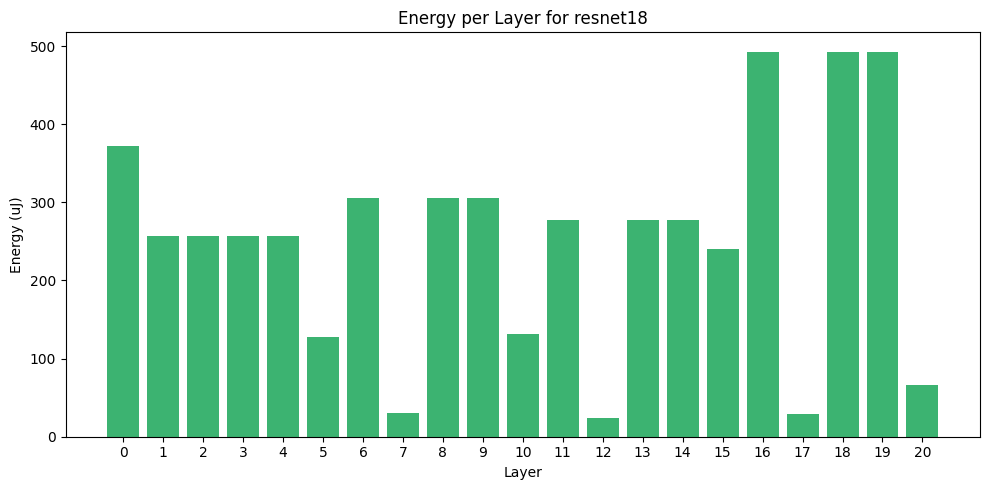

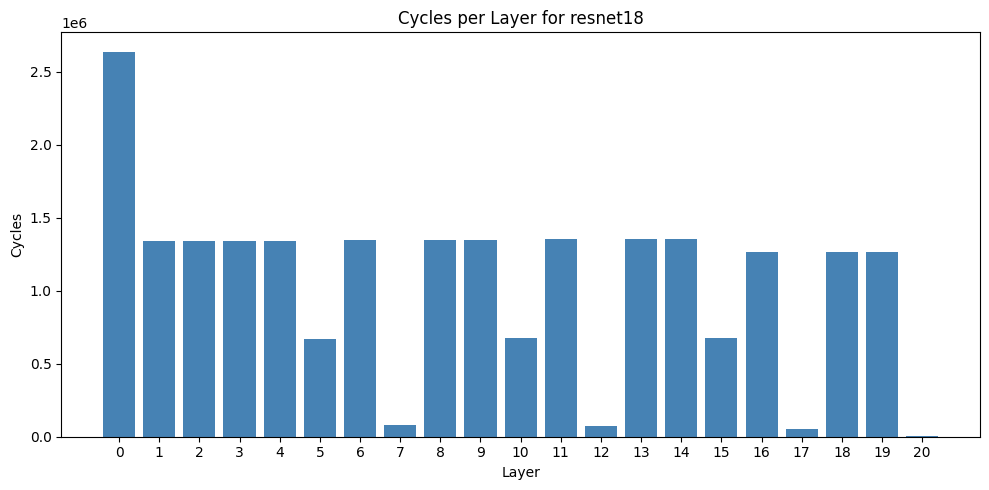

In [27]:
layer_data = extract_outputs("resnet18", "resnet18_128")
plot_energy_and_cycles_per_layer(layer_data)

In [10]:
all_layers_percent

{'00': {'mac': 21.128177461838725,
  'output_activation_reg': 3.3207451366189584,
  'input_activation_reg': 3.3899273269651866,
  'weight_reg': 3.3899273269651866,
  'pe_spad': 0.0174542223350576,
  'shared_glb': 37.41614039541747,
  'DRAM': 31.337628129859418},
 '01': {'mac': 29.92708932681243,
  'output_activation_reg': 4.668171029919447,
  'input_activation_reg': 4.801675776754891,
  'weight_reg': 4.801675776754891,
  'pe_spad': 0.04944620253164557,
  'shared_glb': 19.987503596087457,
  'DRAM': 35.76443829113924},
 '02': {'mac': 29.92708932681243,
  'output_activation_reg': 4.668171029919447,
  'input_activation_reg': 4.801675776754891,
  'weight_reg': 4.801675776754891,
  'pe_spad': 0.04944620253164557,
  'shared_glb': 19.987503596087457,
  'DRAM': 35.76443829113924},
 '03': {'mac': 29.92708932681243,
  'output_activation_reg': 4.668171029919447,
  'input_activation_reg': 4.801675776754891,
  'weight_reg': 4.801675776754891,
  'pe_spad': 0.04944620253164557,
  'shared_glb': 19.9875

In [11]:
layer_data

[{'Layer': 0, 'Energy (uJ)': 371.87, 'Cycles': 2638944.0},
 {'Layer': 1, 'Energy (uJ)': 257.18, 'Cycles': 1342208.0},
 {'Layer': 2, 'Energy (uJ)': 257.18, 'Cycles': 1342208.0},
 {'Layer': 3, 'Energy (uJ)': 257.18, 'Cycles': 1342208.0},
 {'Layer': 4, 'Energy (uJ)': 257.18, 'Cycles': 1342208.0},
 {'Layer': 5, 'Energy (uJ)': 128.09, 'Cycles': 671104.0},
 {'Layer': 6, 'Energy (uJ)': 305.75, 'Cycles': 1348480.0},
 {'Layer': 7, 'Energy (uJ)': 29.76, 'Cycles': 83328.0},
 {'Layer': 8, 'Energy (uJ)': 305.75, 'Cycles': 1348480.0},
 {'Layer': 9, 'Energy (uJ)': 305.75, 'Cycles': 1348480.0},
 {'Layer': 10, 'Energy (uJ)': 131.12, 'Cycles': 674240.0},
 {'Layer': 11, 'Energy (uJ)': 277.3, 'Cycles': 1351616.0},
 {'Layer': 12, 'Energy (uJ)': 23.59, 'Cycles': 72128.0},
 {'Layer': 13, 'Energy (uJ)': 277.3, 'Cycles': 1351616.0},
 {'Layer': 14, 'Energy (uJ)': 277.3, 'Cycles': 1351616.0},
 {'Layer': 15, 'Energy (uJ)': 240.01, 'Cycles': 675808.0},
 {'Layer': 16, 'Energy (uJ)': 492.97, 'Cycles': 1267169.0},
 {

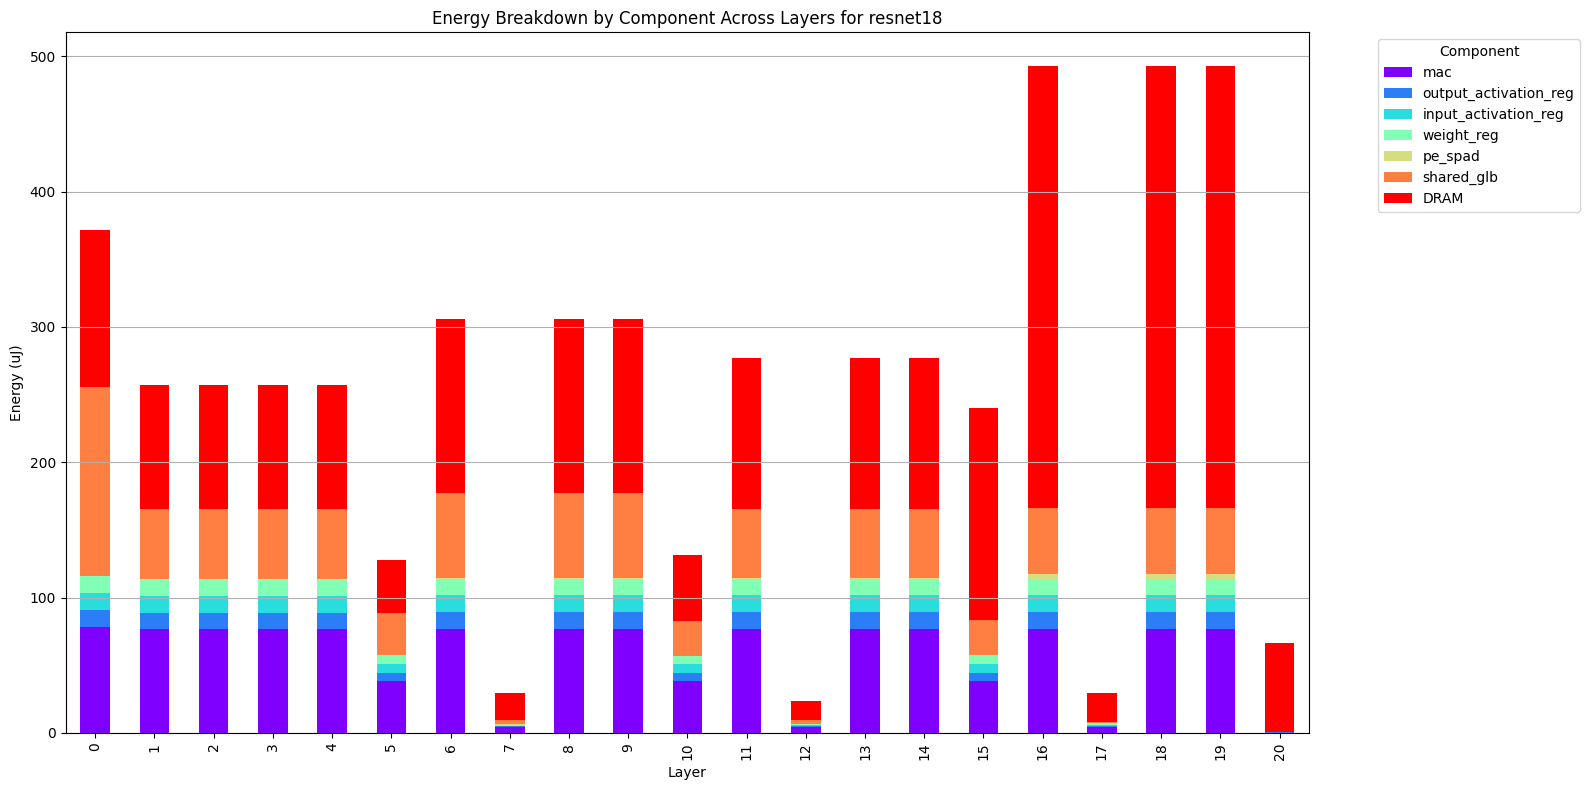

In [25]:
component_energy_by_layer = []
for entry in layer_data:
    layer_index = entry['Layer']
    layer_key = f"{layer_index:02d}"
    total_energy = entry['Energy (uJ)']
    percent_dict = all_layers_percent.get(layer_key, {})
    
    component_energies = {'Layer': layer_index}
    for component, percent in percent_dict.items():
        component_energies[component] = (percent / 100.0) * total_energy
    
    component_energy_by_layer.append(component_energies)

# Convert to DataFrame
df = pd.DataFrame(component_energy_by_layer)
df.set_index('Layer', inplace=True)
df.fillna(0, inplace=True)

# Plot stacked bar chart
from matplotlib import colormaps
import numpy as np
colors = plt.get_cmap('rainbow')(np.linspace(0, 1, df.shape[1]))# You can also use 'Set3', 'nipy_spectral', 'rainbow'
ax = df.plot(kind='bar', stacked=True, figsize=(16, 8), color=colors)

plt.ylabel('Energy (uJ)')
plt.title('Energy Breakdown by Component Across Layers for resnet18')
plt.legend(title='Component', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y')
plt.show()

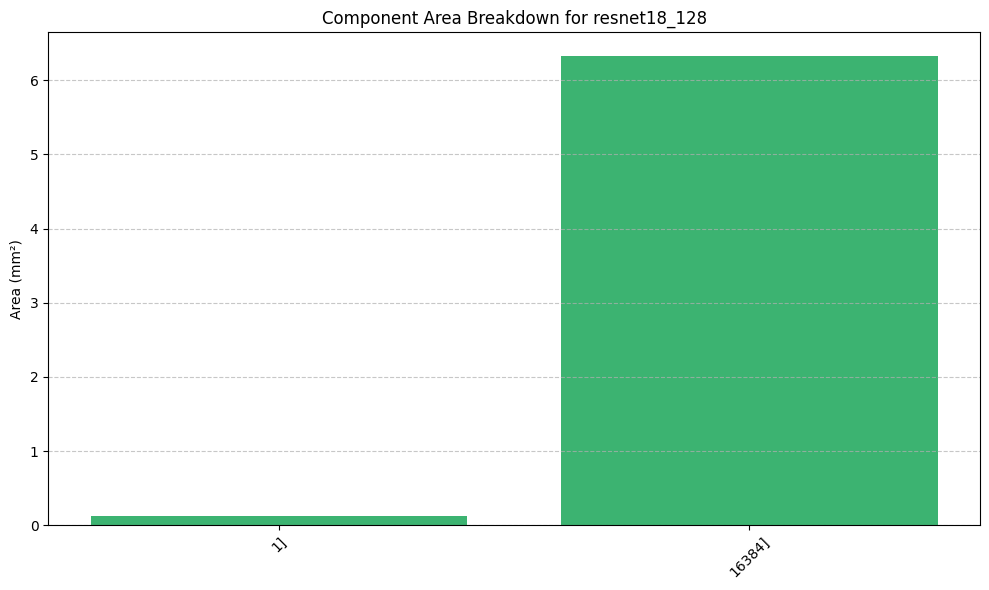

In [31]:
import os
import matplotlib.pyplot as plt

def plot_art_area_components(arch_dir):
    output_dir = os.path.join(".", arch_dir, "outputs")
    art_file = None

    # Find one ART.yaml file
    for subfolder in os.listdir(output_dir):
        sub_path = os.path.join(output_dir, subfolder)
        if os.path.isdir(sub_path):
            candidate = os.path.join(sub_path, "timeloop-mapper.ART.yaml")
            if os.path.isfile(candidate):
                art_file = candidate
                break

    if not art_file:
        print("No ART file found.")
        return

    # Extract areas
    component_areas = {}
    with open(art_file, 'r') as f:
        lines = f.readlines()
        for i in range(len(lines) - 1):
            if 'name:' in lines[i] and 'area:' in lines[i + 1]:
                # Example name line: system_top_level.mac[1..16384]
                raw_name = lines[i].split(':')[1].strip()  # full name
                base_name = raw_name.split('.')[-1].split('[')[0]  # extract "mac", "DRAM", etc.
                count_range = raw_name.split('[')[-1].split('..')[-1].replace(']', '').strip()
                count = float(count_range)
                per_unit_area = float(lines[i + 1].split(':')[1].strip())
                total_area_mm2 = count * per_unit_area * 1e-6
                component_areas[base_name] = total_area_mm2

    # Plot
    names = list(component_areas.keys())
    areas = list(component_areas.values())

    plt.figure(figsize=(10, 6))
    plt.bar(names, areas, color='mediumseagreen')
    plt.ylabel("Area (mm²)")
    plt.title(f"Component Area Breakdown for {arch_dir}")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Example usage
plot_art_area_components("resnet18_128")


In [35]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Energy/inference (J) \t Area (mm2) \t Throughput (inf/s)")

    energy = 0.0
    area = 0.0
    cycles = 0.0
    throughput = 0.0

    for subfolder in os.listdir(output_dir):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        # Parse energy and cycles
        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        energy += float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        cycles += float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        # Parse area only once (assume same design)
        if area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        # Try to extract the component name in a cleaner way
                        name_parts = name_line.split(":")
                        if len(name_parts) >= 2:
                            component_name = name_parts[1].strip().strip('"')
                        else:
                            component_name = "Unknown"

                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        component_area = count * area_per_unit
                        area += component_area
                        print(f"Component: {component_name}, Count: {count}, Area/unit: {area_per_unit}, Total area: {component_area}")
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")
                continue

    # Convert units
    energy *= 1e-6  # uJ to J
    area *= 1e-6    # um² to mm²
    throughput = 1 / (cycles * 1e-9) if cycles > 0 else 0  # inf/s

    print("{} \t {:.2e} \t {:.2f} \t {:.2e}".format(model, energy, area, throughput))
    return energy, area, throughput

# Example call
extract_outputs("resnet18", "resnet18_128")


Scanning in: ./resnet18_128/outputs
Model 	 Energy/inference (J) 	 Area (mm2) 	 Throughput (inf/s)
Component: system_top_level.DRAM[1..1], Count: 1.0, Area/unit: 0.0, Total area: 0.0
Component: system_top_level.inter_PE_spatial[1..1], Count: 1.0, Area/unit: 1.0, Total area: 1.0
Component: system_top_level.weight_reg[1..16384], Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: system_top_level.input_activation_reg[1..16384], Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: system_top_level.output_activation_reg[1..16384], Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: system_top_level.shared_glb[1..1], Count: 1.0, Area/unit: 118878.0, Total area: 118878.0
Component: system_top_level.pe_spad[1..16384], Count: 16384.0, Area/unit: 340.999, Total area: 5586927.616
Component: system_top_level.mac[1..16384], Count: 16384.0, Area/unit: 386.311, Total area: 6329319.424
resnet18 	 5.28e-03 	 15.43 	 4.52e+01


(0.005277200000000001, 15.425409815999998, 45.16639412511678)

Scanning in: ./resnet18_128/outputs
Model 	 Energy/inference (J) 	 Area (mm2) 	 Throughput (inf/s)
Component: system_top_level.DRAM[1..1], Count: 1.0, Area/unit: 0.0, Total area: 0.0
Component: system_top_level.inter_PE_spatial[1..1], Count: 1.0, Area/unit: 1.0, Total area: 1.0
Component: system_top_level.weight_reg[1..16384], Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: system_top_level.input_activation_reg[1..16384], Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: system_top_level.output_activation_reg[1..16384], Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: system_top_level.shared_glb[1..1], Count: 1.0, Area/unit: 118878.0, Total area: 118878.0
Component: system_top_level.pe_spad[1..16384], Count: 16384.0, Area/unit: 340.999, Total area: 5586927.616
Component: system_top_level.mac[1..16384], Count: 16384.0, Area/unit: 386.311, Total area: 6329319.424
resnet18 	 5.28e-03 	 15.43 	 4.52e+01


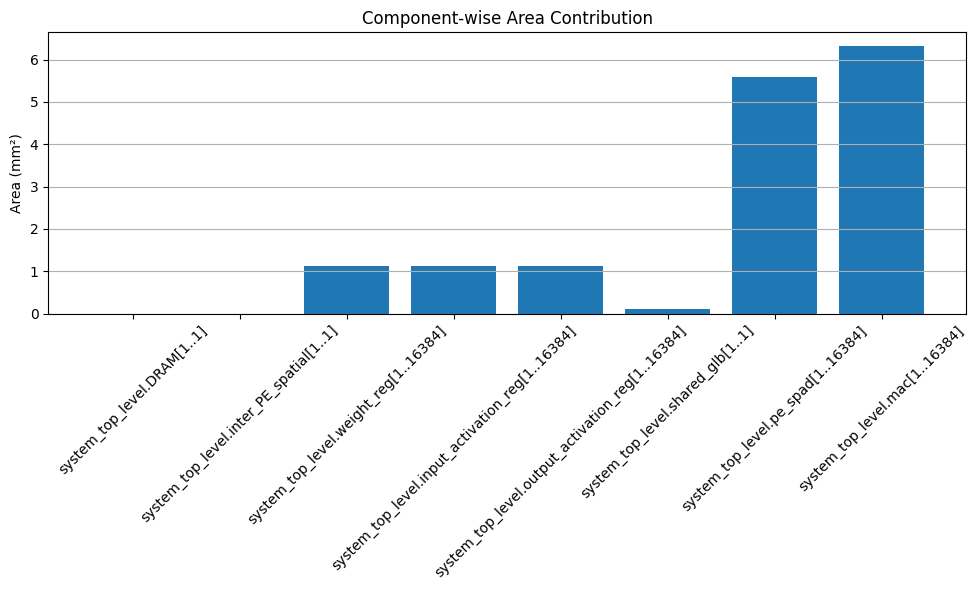

(0.005277200000000001, 15.425409815999998, 45.16639412511678)

In [36]:
import os
import matplotlib.pyplot as plt

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Energy/inference (J) \t Area (mm2) \t Throughput (inf/s)")

    energy = 0.0
    area = 0.0
    cycles = 0.0
    throughput = 0.0
    component_areas = {}

    for subfolder in os.listdir(output_dir):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        # Parse energy and cycles
        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        energy += float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        cycles += float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        # Parse area only once (assume same design)
        if area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        # Extract component name
                        name_parts = name_line.split(":")
                        if len(name_parts) >= 2:
                            component_name = name_parts[1].strip().strip('"')
                        else:
                            component_name = "Unknown"

                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        component_area = count * area_per_unit
                        area += component_area
                        component_areas[component_name] = component_area
                        print(f"Component: {component_name}, Count: {count}, Area/unit: {area_per_unit}, Total area: {component_area}")
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")
                continue

    # Convert units
    energy *= 1e-6  # uJ to J
    area *= 1e-6    # um² to mm²
    throughput = 1 / (cycles * 1e-9) if cycles > 0 else 0  # inf/s

    print("{} \t {:.2e} \t {:.2f} \t {:.2e}".format(model, energy, area, throughput))

    # Plot bar chart
    if component_areas:
        components = list(component_areas.keys())
        areas_mm2 = [a * 1e-6 for a in component_areas.values()]

        plt.figure(figsize=(10, 6))
        plt.bar(components, areas_mm2)
        plt.ylabel("Area (mm²)")
        plt.title("Component-wise Area Contribution")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.grid(axis='y')
        plt.show()

    return energy, area, throughput

# Example call
extract_outputs("resnet18", "resnet18_128")


Scanning in: ./resnet18_128/outputs
Model 	 Energy/inference (J) 	 Area (mm2) 	 Throughput (inf/s)
Component: DRAM, Count: 1.0, Area/unit: 0.0, Total area: 0.0
Component: inter_PE_spatial, Count: 1.0, Area/unit: 1.0, Total area: 1.0
Component: weight_reg, Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: input_activation_reg, Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: output_activation_reg, Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: shared_glb, Count: 1.0, Area/unit: 118878.0, Total area: 118878.0
Component: pe_spad, Count: 16384.0, Area/unit: 340.999, Total area: 5586927.616
Component: mac, Count: 16384.0, Area/unit: 386.311, Total area: 6329319.424
resnet18 	 5.28e-03 	 15.43 	 4.52e+01


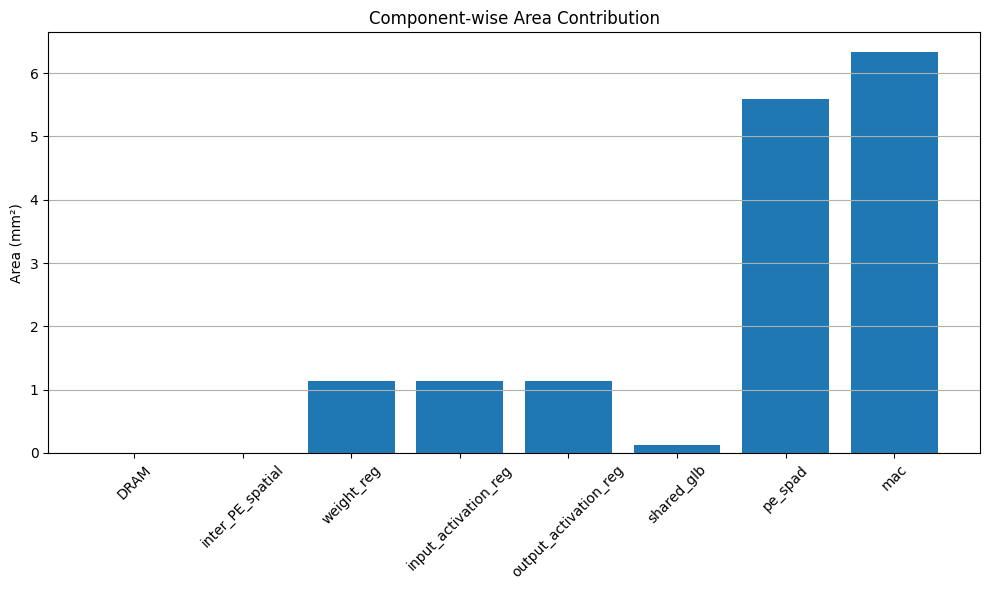

(0.005277200000000001, 15.425409815999998, 45.16639412511678)

In [38]:
import os
import matplotlib.pyplot as plt
import re

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Energy/inference (J) \t Area (mm2) \t Throughput (inf/s)")

    energy = 0.0
    area = 0.0
    cycles = 0.0
    throughput = 0.0
    component_areas = {}

    for subfolder in os.listdir(output_dir):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        # Parse energy and cycles
        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        energy += float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        cycles += float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        # Parse area only once (assume same design)
        if area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        # Extract and clean component name
                        match = re.search(r'name:\s*"?(.*?)"?$', name_line)
                        raw_name = match.group(1) if match else "Unknown"
                        clean_name = raw_name
                        for prefix in ['system_top_level.', 'system.']:
                            if clean_name.startswith(prefix):
                                clean_name = clean_name[len(prefix):]
                        clean_name = re.split(r'\[', clean_name)[0].strip()

                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        component_area = count * area_per_unit
                        area += component_area
                        component_areas[clean_name] = component_area
                        print(f"Component: {clean_name}, Count: {count}, Area/unit: {area_per_unit}, Total area: {component_area}")
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")
                continue

    # Convert units
    energy *= 1e-6  # uJ to J
    area *= 1e-6    # um² to mm²
    throughput = 1 / (cycles * 1e-9) if cycles > 0 else 0  # inf/s

    print("{} \t {:.2e} \t {:.2f} \t {:.2e}".format(model, energy, area, throughput))

    # Plot bar chart
    if component_areas:
        components = list(component_areas.keys())
        areas_mm2 = [a * 1e-6 for a in component_areas.values()]

        plt.figure(figsize=(10, 6))
        plt.bar(components, areas_mm2)
        plt.ylabel("Area (mm²)")
        plt.title("Component-wise Area Contribution")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.grid(axis='y')
        plt.show()

    return energy, area, throughput

# Example call
extract_outputs("resnet18", "resnet18_128")


Scanning in: ./resnet18_128/outputs
Model 	 Energy/inference (J) 	 Area (mm2) 	 Throughput (inf/s)
Component: DRAM, Count: 1.0, Area/unit: 0.0, Total area: 0.0
Component: inter_PE_spatial, Count: 1.0, Area/unit: 1.0, Total area: 1.0
Component: weight_reg, Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: input_activation_reg, Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: output_activation_reg, Count: 16384.0, Area/unit: 68.9755, Total area: 1130094.592
Component: shared_glb, Count: 1.0, Area/unit: 118878.0, Total area: 118878.0
Component: pe_spad, Count: 16384.0, Area/unit: 340.999, Total area: 5586927.616
Component: mac, Count: 16384.0, Area/unit: 386.311, Total area: 6329319.424
resnet18 	 5.28e-03 	 15.43 	 4.52e+01


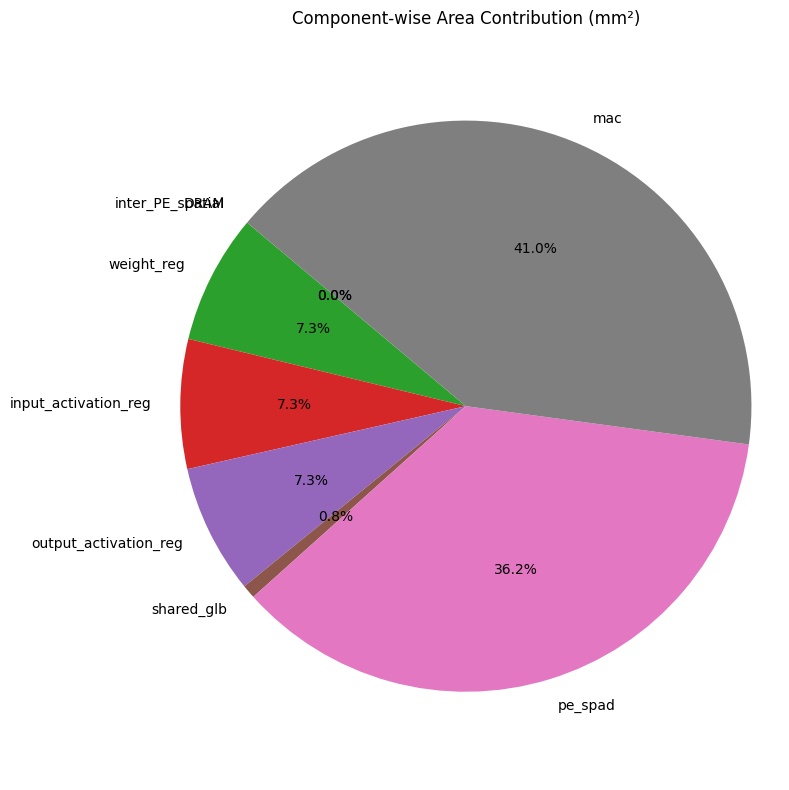

(0.005277200000000001, 15.425409815999998, 45.16639412511678)

In [39]:
import os
import matplotlib.pyplot as plt
import re

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Energy/inference (J) \t Area (mm2) \t Throughput (inf/s)")

    energy = 0.0
    area = 0.0
    cycles = 0.0
    throughput = 0.0
    component_areas = {}

    for subfolder in os.listdir(output_dir):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        # Parse energy and cycles
        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        energy += float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        cycles += float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        # Parse area only once (assume same design)
        if area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        # Extract and clean component name
                        match = re.search(r'name:\s*"?(.*?)"?$', name_line)
                        raw_name = match.group(1) if match else "Unknown"
                        clean_name = raw_name
                        for prefix in ['system_top_level.', 'system.']:
                            if clean_name.startswith(prefix):
                                clean_name = clean_name[len(prefix):]
                        clean_name = re.split(r'\[', clean_name)[0].strip()

                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        component_area = count * area_per_unit
                        area += component_area
                        component_areas[clean_name] = component_area
                        print(f"Component: {clean_name}, Count: {count}, Area/unit: {area_per_unit}, Total area: {component_area}")
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")
                continue

    # Convert units
    energy *= 1e-6  # uJ to J
    area *= 1e-6    # um² to mm²
    throughput = 1 / (cycles * 1e-9) if cycles > 0 else 0  # inf/s

    print("{} \t {:.2e} \t {:.2f} \t {:.2e}".format(model, energy, area, throughput))

    # Plot pie chart
    if component_areas:
        labels = list(component_areas.keys())
        sizes = [a * 1e-6 for a in component_areas.values()]  # Convert to mm²

        plt.figure(figsize=(8, 8))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
        plt.axis('equal')  # Equal aspect ratio ensures pie is circular.
        plt.title("Component-wise Area Contribution (mm²)")
        plt.tight_layout()
        plt.show()

    return energy, area, throughput

# Example call
extract_outputs("resnet18", "resnet18_128")


In [1]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Folder \tEnergy (J) \tCycles \t\tPartial Area (mm²)")

    total_energy = 0.0
    total_area = 0.0
    total_cycles = 0.0

    for subfolder in sorted(os.listdir(output_dir)):  # sorted for consistent order
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        folder_energy = 0.0
        folder_cycles = 0.0
        folder_area = 0.0

        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        folder_energy = float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        folder_cycles = float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        total_energy += folder_energy
        total_cycles += folder_cycles

        # Area only once (from the first available folder)
        if total_area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        folder_area += count * area_per_unit
                total_area = folder_area  # only assign once
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")

        # Print stats for current folder
        print(f"{model} \t {subfolder} \t{folder_energy * 1e-6:.2e} \t{int(folder_cycles)} \t\t{folder_area * 1e-6:.2f}")

    # Final conversion
    total_energy *= 1e-6  # uJ → J
    total_area *= 1e-6    # um² → mm²
    throughput = 1 / (total_cycles * 1e-9) if total_cycles > 0 else 0  # inf/s

    # Final summary
    print("\n=== Total Summary ===")
    print("Model \t\tEnergy/inference (J) \tArea (mm²) \tThroughput (inf/s)")
    print("{:s} \t{:.2e} \t\t{:.2f} \t\t{:.2e}".format(model, total_energy, total_area, throughput))

    return total_energy, total_area, throughput

# Example call
extract_outputs("resnet18", "resnet18_128")

Scanning in: ./resnet18_128/outputs
Model 	 Folder 	Energy (J) 	Cycles 		Partial Area (mm²)
resnet18 	 00 	3.72e-04 	2638944 		15.43
resnet18 	 01 	2.57e-04 	1342208 		0.00
resnet18 	 02 	2.57e-04 	1342208 		0.00
resnet18 	 03 	2.57e-04 	1342208 		0.00
resnet18 	 04 	2.57e-04 	1342208 		0.00
resnet18 	 05 	1.28e-04 	671104 		0.00
resnet18 	 06 	3.06e-04 	1348480 		0.00
resnet18 	 07 	2.98e-05 	83328 		0.00
resnet18 	 08 	3.06e-04 	1348480 		0.00
resnet18 	 09 	3.06e-04 	1348480 		0.00
resnet18 	 10 	1.31e-04 	674240 		0.00
resnet18 	 11 	2.77e-04 	1351616 		0.00
resnet18 	 12 	2.36e-05 	72128 		0.00
resnet18 	 13 	2.77e-04 	1351616 		0.00
resnet18 	 14 	2.77e-04 	1351616 		0.00
resnet18 	 15 	2.40e-04 	675808 		0.00
resnet18 	 16 	4.93e-04 	1267169 		0.00
resnet18 	 17 	2.95e-05 	50176 		0.00
resnet18 	 18 	4.93e-04 	1267169 		0.00
resnet18 	 19 	4.93e-04 	1267169 		0.00
resnet18 	 20 	6.65e-05 	4000 		0.00

=== Total Summary ===
Model 		Energy/inference (J) 	Area (mm²) 	Throughput (in

(0.005277200000000001, 15.425409815999998, 45.16639412511678)